
## **Tackling CIFAR-10 With a DNN/CNN**





In this work, you need to modify the colab file to complete the CIFAR-10 task with a CNN. Please submit the completed colab file to Canvas (PRMLS Day 2 workshop submission).

Moreover, what kind(s) of setup/configuration does the colab training recipe use (not found in our lecturer slides) so that we can rapidly complete model training?

Please provide your answer below:

**[Answer here]**

The Colab recipe uses a GPU hardware accelerator. CNN training involves many parallel matrix operations, and a GPU performs these far faster than a CPU.

It also uses mini-batch training and Keras callbacks such as `ModelCheckpoint` and `CSVLogger`. Mini-batches improve training throughput, while callbacks save the best validation model and record training results.

---


## **1. Import libraries**



In [1]:
# Python ≥3.5 is asserted
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is asserted
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is asserted
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger,LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import optimizers

print("Versions of key libraries")
print("---")
print("tensorflow: ", tf.__version__)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)


No GPU was detected. CNNs can be very slow without a GPU.
Versions of key libraries
---
tensorflow:  2.15.1
numpy:       1.24.4
matplotlib:  3.10.9
sklearn:     1.7.1


## **2. Matplotlib setup**

In [2]:
plt.style.use('ggplot')
plt.rcParams['ytick.right']	= True
plt.rcParams['ytick.labelright']=	True
plt.rcParams['ytick.left']	= False
plt.rcParams['ytick.labelleft'] = False
plt.rcParams['font.family']	= 'Arial'

## **3. Data preparation**



In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = ((X_train - X_mean) / X_std).astype('float32')
X_valid = ((X_valid - X_mean) / X_std).astype('float32')
X_test = ((X_test - X_mean) / X_std).astype('float32')


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 [==============================] - 1878s 11us/step


In [4]:
print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_train.shape)
print("y_train.shape =", y_train.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_valid.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)


X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (45000, 32, 32, 3)
y_train.shape = (45000, 1)
X_valid.shape = (5000, 32, 32, 3)
y_valid.shape = (5000, 1)
X_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)


## **4. Define model**

In [5]:
# CNN model for CIFAR-10
imgrows = X_train_full.shape[1]
imgclms = X_train_full.shape[2]
channel = X_train_full.shape[3]
num_classes = 10

model = keras.Sequential([
    keras.layers.Input(shape=(imgrows, imgclms, channel)),
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(num_classes, activation="softmax")
])
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 64)       

In [6]:
# Import to_categorical for one-hot encoding
# from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)

(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [7]:
# Compile and configure checkpoint/logging callbacks
optmz = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss="categorical_crossentropy", optimizer=optmz, metrics=["accuracy"])
modelname = "cifar10"
filepath = modelname + ".keras"
# 需要改为新版接口
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
csv_logger = CSVLogger(modelname + '.csv')
callbacks_list = [checkpoint, csv_logger]


## **5 & 6. Train and test a model**

In [8]:
# Train the CNN with image tensors (no flattening).
history = model.fit(X_train, y_train_encoded, epochs=5, batch_size=128,
                    validation_data=(X_valid, y_valid_encoded), callbacks=callbacks_list, verbose=2)
score = model.evaluate(X_test, y_test_encoded, verbose=0)
X_new = X_test[:10]
y_pred = model.predict(X_new, verbose=0)


Epoch 1/5



Epoch 1: val_accuracy improved from -inf to 0.38400, saving model to cifar10.keras
352/352 - 8s - loss: 1.6551 - accuracy: 0.4165 - val_loss: 2.2514 - val_accuracy: 0.3840 - 8s/epoch - 24ms/step
Epoch 2/5

Epoch 2: val_accuracy improved from 0.38400 to 0.61780, saving model to cifar10.keras
352/352 - 7s - loss: 1.2872 - accuracy: 0.5452 - val_loss: 1.1171 - val_accuracy: 0.6178 - 7s/epoch - 20ms/step
Epoch 3/5

Epoch 3: val_accuracy improved from 0.61780 to 0.66720, saving model to cifar10.keras
352/352 - 7s - loss: 1.1145 - accuracy: 0.6100 - val_loss: 0.9626 - val_accuracy: 0.6672 - 7s/epoch - 20ms/step
Epoch 4/5

Epoch 4: val_accuracy improved from 0.66720 to 0.71220, saving model to cifar10.keras
352/352 - 10s - loss: 0.9966 - accuracy: 0.6518 - val_loss: 0.8371 - val_accuracy: 0.7122 - 10s/epoch - 27ms/step
Epoch 5/5

Epoch 5: val_accuracy improved from 0.71220 to 0.73000, saving model to cifar10.keras
352/352 - 7s - loss: 0.8949 - accuracy: 0.6861 - val_loss: 0.8051 

In [9]:
model.save_weights(modelname + ".weights.h5", overwrite=True)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_encoded.shape)
print("test loss, test accuracy:", score)
print("modelname =", modelname)

# 本地使移除linux shell指令
from pathlib import Path
print("saved files:", [p.name for p in Path.cwd().glob("cifar10*")])


X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)
test loss, test accuracy: [0.8285648226737976, 0.7195000052452087]
modelname = cifar10
saved files: ['cifar10.csv', 'cifar10.keras', 'cifar10.weights.h5']


In [10]:
# Calculate accuracy and confusion matrix
y_pred = model.predict(X_test, verbose=0)
predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
labelname = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
testScores = metrics.accuracy_score(testout, predout)
confusion = metrics.confusion_matrix(testout, predout)
print("Test accuracy: %.2f%%" % (testScores * 100))
print(metrics.classification_report(testout, predout, labels=np.arange(num_classes), target_names=labelname, digits=4, zero_division=0))
print(confusion)


Test accuracy: 71.95%
              precision    recall  f1-score   support

    airplane     0.8041    0.6980    0.7473      1000
  automobile     0.8225    0.8710    0.8460      1000
        bird     0.6291    0.5750    0.6008      1000
         cat     0.5946    0.4650    0.5219      1000
        deer     0.5806    0.7710    0.6624      1000
         dog     0.6629    0.5230    0.5847      1000
        frog     0.7619    0.8290    0.7941      1000
       horse     0.7227    0.7950    0.7571      1000
        ship     0.7654    0.8970    0.8260      1000
       truck     0.8567    0.7710    0.8116      1000

    accuracy                         0.7195     10000
   macro avg     0.7200    0.7195    0.7152     10000
weighted avg     0.7200    0.7195    0.7152     10000

[[698  26  60  13  32   4   5  16 119  27]
 [ 11 871   4   4   8   0   7   3  42  50]
 [ 58   4 575  34 151  49  64  47  14   4]
 [ 12   6  79 465 108 144  83  62  27  14]
 [ 18   2  47  23 771  12  51  62  13   1]
 [ 1

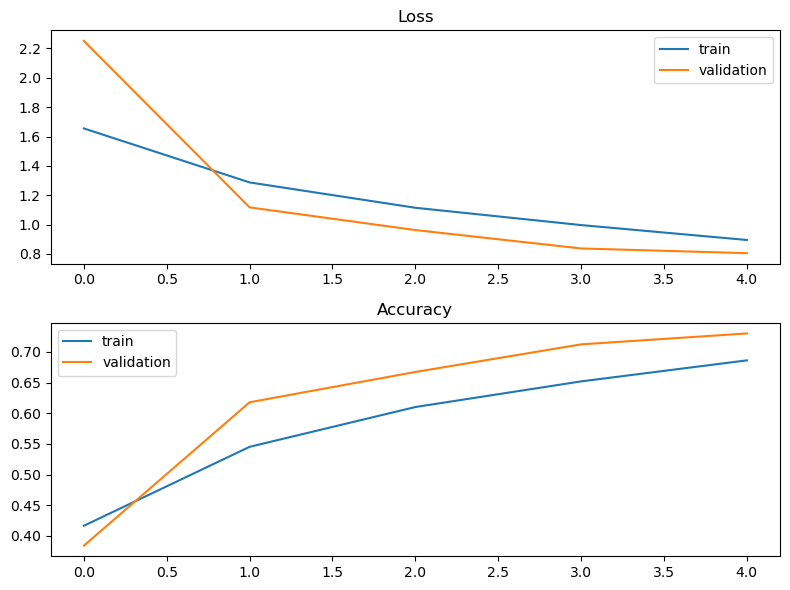

In [11]:
records = pd.read_csv(modelname + ".csv")
plt.figure(figsize=(8, 6))
plt.subplot(211)
plt.plot(records["loss"], label="train")
plt.plot(records["val_loss"], label="validation")
plt.title("Loss")
plt.legend()
plt.subplot(212)
plt.plot(records["accuracy"], label="train")
plt.plot(records["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()
